In [1]:
import pandas as pd
import numpy as np

path = "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(path)

print(df.shape)
df.head(3)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# Standardize target to 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert commonly tricky numeric column (TotalCharges sometimes has blanks)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop leaky/non-informative identifiers
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Missingness overview
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


,0
TotalCharges,11


Churn rate: 0.265


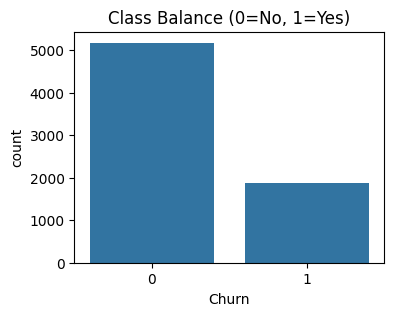

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Churn rate:", df['Churn'].mean().round(3))

plt.figure(figsize=(4,3))
sns.countplot(x='Churn', data=df)
plt.title('Class Balance (0=No, 1=Yes)')
plt.show()


In [5]:
from sklearn.model_selection import train_test_split

target = 'Churn'
X = df.drop(columns=[target])
y = df[target]

numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','bool','category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features, categorical_features[:5]  # sanity check

(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines'])

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Baseline AUC: 0.841
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[747 288]
 [ 81 293]]


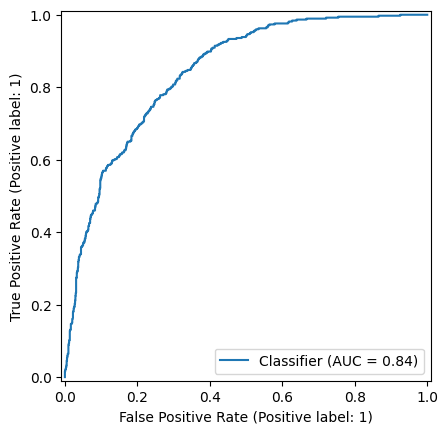

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg.fit(X_train, y_train)
probs = log_reg.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

print("Baseline AUC:", roc_auc_score(y_test, probs).round(3))
print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))
RocCurveDisplay.from_predictions(y_test, probs)
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline

# 1) Slightly leaner one-hot to reduce columns:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # drop='if_binary' reduces one-hot width for binary cols
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# 2) Smaller forest first (you can increase later)
rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1  # use all cores
    ))
])

# 3) Randomized search: 12 trials × 3-fold CV = 36 fits (fast)
param_distributions = {
    "model__max_depth": [None, 6, 10, 16],
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__max_features": ["sqrt", "log2", 0.5]  # try a few
}

rand = RandomizedSearchCV(
    rf,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2,    # <-- progress in console
    refit=True
)

rand.fit(X_train, y_train)

best_model = rand.best_estimator_
print("Best CV AUC:", rand.best_score_)
probs_rf = best_model.predict_proba(X_test)[:, 1]
print("Test AUC:", roc_auc_score(y_test, probs_rf).round(3))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best CV AUC: 0.8479938773734981
Test AUC: 0.845


In [28]:
# STEP 2A — Save your model bundle
import os, joblib
os.makedirs("churn_prediction/models", exist_ok=True)

model_bundle = {
    "model": best_model,           # the fitted Pipeline (preprocess + classifier)
    "threshold": float(best_thr),  # tuned decision threshold from your PR-curve step
    "meta": {
        "target": "Churn",
        "notes": "RandomForest pipeline + tuned threshold",
    },
}

save_path = "churn_prediction/models/churn_rf_bundle.joblib"
joblib.dump(model_bundle, save_path)
print(f"✅ Saved model bundle to: {save_path}")

✅ Saved model bundle to: churn_prediction/models/churn_rf_bundle.joblib


In [29]:
# STEP 2B — Load it back and run a tiny test to confirm
import pandas as pd, joblib

bundle = joblib.load("churn_prediction/models/churn_rf_bundle.joblib")
clf = bundle["model"]
thr  = bundle["threshold"]

# use a single example row (update keys if your column names differ)
example = {
  "gender": "Female",
  "SeniorCitizen": 0,
  "Partner": "Yes",
  "Dependents": "No",
  "tenure": 5,
  "PhoneService": "Yes",
  "MultipleLines": "No",
  "InternetService": "Fiber optic",
  "OnlineSecurity": "No",
  "OnlineBackup": "Yes",
  "DeviceProtection": "No",
  "TechSupport": "No",
  "StreamingTV": "Yes",
  "StreamingMovies": "Yes",
  "Contract": "Month-to-month",
  "PaperlessBilling": "Yes",
  "PaymentMethod": "Electronic check",
  "MonthlyCharges": 85.5,
  "TotalCharges": 400.2
}

prob = clf.predict_proba(pd.DataFrame([example]))[:, 1][0]
pred = int(prob >= thr)
print({"probability": float(prob), "churn_pred": pred, "threshold_used": thr})

{'probability': 0.8616716235366613, 'churn_pred': 1, 'threshold_used': 0.5581380618679895}


In [11]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, probs_rf)
f1 = (2 * prec * rec) / (prec + rec + 1e-9)
ix = np.nanargmax(f1)
best_thr = thr[ix]
best_thr, prec[ix], rec[ix], f1[ix]

(np.float64(0.5581380618679895),
 np.float64(0.5595959595959596),
 np.float64(0.7406417112299465),
 np.float64(0.6375143838595214))

In [12]:
preds_thr = (probs_rf >= best_thr).astype(int)
print(classification_report(y_test, preds_thr))
confusion_matrix(y_test, preds_thr)

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.74      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



array([[817, 218],
       [ 97, 277]])

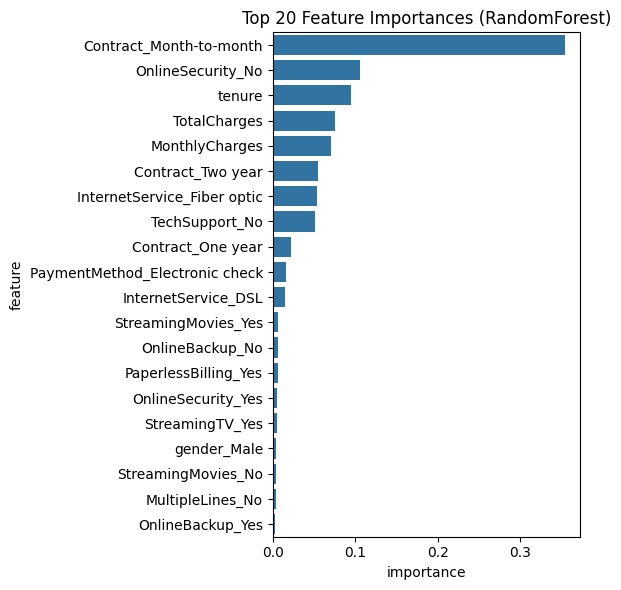

In [13]:
# Get one-hot feature names
ohe = best_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
ohe_feats = ohe.get_feature_names_out(categorical_features)
num_feats = numeric_features
all_feats = np.concatenate([num_feats, ohe_feats])

rf_clf = best_model.named_steps["model"]
importances = rf_clf.feature_importances_

# Top 20 features
imp_df = pd.DataFrame({"feature": all_feats, "importance": importances}) \
    .sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(6,6))
sns.barplot(data=imp_df, y="feature", x="importance", orient='h')
plt.title("Top 20 Feature Importances (RandomForest)")
plt.tight_layout()
plt.show()

In [16]:
import os, json, joblib
from datetime import datetime

# 1) Ensure output folder exists
os.makedirs("models", exist_ok=True)

# 2) Bundle EVERYTHING you need at inference in one dict
#    - model: your fitted sklearn Pipeline (preprocess + classifier)
#    - threshold: tuned decision threshold (float)
#    - meta: useful info for debugging/repro
model_bundle = {
    "model": best_model,            # from your search (Grid/Randomized)
    "threshold": float(best_thr),   # from your threshold tuning step
    "meta": {
        "created_at": datetime.utcnow().isoformat() + "Z",
        "framework": "scikit-learn",
        "version_hints": {
            # keep for your own notes; optional
            "sklearn_min": "1.2",   # if you used OneHotEncoder(sparse_output=...)
        },
        "target": "Churn"
    }
}

# 3) Save the bundle with joblib
bundle_path = "models/churn_rf_bundle.joblib"
joblib.dump(model_bundle, bundle_path)

print(f"Saved model bundle -> {bundle_path}")


Saved model bundle -> models/churn_rf_bundle.joblib


/tmp/ipykernel_291/791659485.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z",


In [17]:
import joblib
import pandas as pd

# Load
bundle = joblib.load("models/churn_rf_bundle.joblib")
clf = bundle["model"]
thr = bundle["threshold"]

def predict_one(sample: dict):
    """sample: a dict whose keys match your training columns."""
    X_new = pd.DataFrame([sample])
    prob = clf.predict_proba(X_new)[:, 1][0]
    return {
        "probability": float(prob),
        "churn_pred": int(prob >= thr),
        "threshold_used": thr
    }

def predict_batch(df: pd.DataFrame):
    """df: DataFrame with the same columns as training features."""
    probs = clf.predict_proba(df)[:, 1]
    preds = (probs >= thr).astype(int)
    out = df.copy()
    out["churn_probability"] = probs
    out["churn_pred"] = preds
    return out

In [18]:
example = {
  "gender": "Female",
  "SeniorCitizen": 0,
  "Partner": "Yes",
  "Dependents": "No",
  "tenure": 5,
  "PhoneService": "Yes",
  "MultipleLines": "No",
  "InternetService": "Fiber optic",
  "OnlineSecurity": "No",
  "OnlineBackup": "Yes",
  "DeviceProtection": "No",
  "TechSupport": "No",
  "StreamingTV": "Yes",
  "StreamingMovies": "Yes",
  "Contract": "Month-to-month",
  "PaperlessBilling": "Yes",
  "PaymentMethod": "Electronic check",
  "MonthlyCharges": 85.5,
  "TotalCharges": 400.2
}
print(predict_one(example))

{'probability': 0.8616716235366613, 'churn_pred': 1, 'threshold_used': 0.5581380618679895}


In [24]:
# Create main project folder
!mkdir -p churn_prediction

# Create sub-folders inside it
!mkdir -p churn_prediction/models
!mkdir -p churn_prediction/notebooks
!mkdir -p churn_prediction/src

In [25]:
# Save a copy of your current notebook into the project folder
from google.colab import files
# Note: In the Colab menu, go to File → Save a copy in Drive

In [27]:
import os
os.makedirs("churn_prediction/models", exist_ok=True)

In [30]:
!mkdir -p churn_prediction/notebooks
!mkdir -p churn_prediction/src

In [35]:
!ls

churn_prediction  models  sample_data  WA_Fn-UseC_-Telco-Customer-Churn.csv
